# Task 2: Stock Price Prediction

## Objective
The objective of this project is to predict the next day's stock closing price using Machine Learning. We use historical stock market data and train a Linear Regression model to make predictions.

## Intern
Hamza Khalil

## Internship
DevelopersHub AI/ML Engineering Internship

In [3]:
!pip install yfinance

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Download Apple stock data

ticker = "AAPL"

df = yf.download(
    ticker,
    start="2022-01-01",
    end="2024-01-01"
)

df.head()

/tmp/ipykernel_1141/1643275465.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939682,178.790236,173.735855,173.853167,104487900
2022-01-04,175.681366,178.848915,175.114335,178.545850,99310400
2022-01-05,171.008255,176.140849,170.734518,175.593375,94537600
2022-01-06,168.153580,171.379785,167.801630,168.837923,96904000
2022-01-07,168.319748,170.245694,167.205242,169.023648,86709100


In [6]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (501, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2022-01-03 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   501 non-null    float64
 1   (High, AAPL)    501 non-null    float64
 2   (Low, AAPL)     501 non-null    float64
 3   (Open, AAPL)    501 non-null    float64
 4   (Volume, AAPL)  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,501.000000,501.000000,501.000000,501.000000,5.010000e+02
mean,160.981679,162.643736,159.157568,160.822130,7.359559e+07
std,17.710739,17.443341,17.972579,17.743000,2.536654e+07
min,122.933540,125.637646,122.097730,123.906996,2.404830e+07
25%,146.648422,148.253912,144.773764,146.136419,5.414710e+07
50%,161.887604,163.084950,159.567642,161.496057,6.924600e+07
75%,173.880112,175.361394,171.974217,173.853167,8.670910e+07
max,195.892624,197.385718,194.795046,195.803635,1.826020e+08


In [7]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [8]:
# Create target column (Next Day Close Price)
df["Next_Close"] = df["Close"].shift(-1)

# Remove last row (it has no next day value)
df.dropna(inplace=True)

# Display first 5 rows
df.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2022-01-03,177.939682,178.790236,173.735855,173.853167,104487900,175.681366
2022-01-04,175.681366,178.848915,175.114335,178.545850,99310400,171.008255
2022-01-05,171.008255,176.140849,170.734518,175.593375,94537600,168.153580
2022-01-06,168.153580,171.379785,167.801630,168.837923,96904000,168.319748
2022-01-07,168.319748,170.245694,167.205242,169.023648,86709100,168.339310


In [9]:
# Input features
X = df[["Open", "High", "Low", "Close", "Volume"]]

# Target
y = df["Next_Close"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (500, 5)
Target Shape: (500,)


In [10]:
# Split into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 400
Testing Samples: 100


In [11]:
# Train Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
# Predict stock prices

y_pred = model.predict(X_test)

print("First 10 Predictions:")

print(y_pred[:10])

First 10 Predictions:
[176.78695629 175.01642732 175.22037899 175.38261404 176.89472684
 174.94499592 174.34184939 171.3090217  172.12145927 173.29374783]


In [13]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 1.7222069345013429
R² Score: 0.9344527419068623


### Observation

- The Linear Regression model was trained using historical Apple stock prices.
- The model predicts the next day's closing price.
- Mean Absolute Error (MAE) measures the average prediction error.
- R² Score indicates how well the model fits the data. A value closer to 1 means better performance.

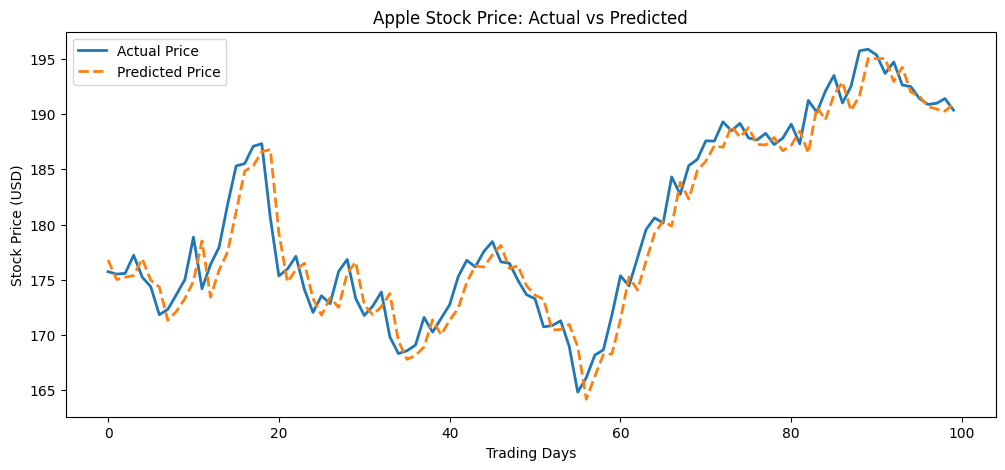

In [14]:
# Plot Actual vs Predicted Prices

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual Price", linewidth=2)

plt.plot(y_pred, label="Predicted Price", linestyle="--", linewidth=2)

plt.title("Apple Stock Price: Actual vs Predicted")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price (USD)")
plt.legend()

plt.show()

# Conclusion

In this project, we developed a Linear Regression model to predict the next day's Apple stock closing price.

### Key Findings
- Historical Apple stock data was downloaded using the yfinance library.
- The data was preprocessed and used to train a Linear Regression model.
- The model successfully predicted the next day's closing prices.
- The Actual vs Predicted graph shows that the model follows the overall stock price trend.
- The model performance was evaluated using Mean Absolute Error (MAE) and R² Score.

This project demonstrates how Machine Learning can be used for stock price prediction using historical financial data.